# Data distribution experiments and understanding

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import gsw
import numpy as np
from mpl_toolkits.basemap import Basemap

In [2]:
# Get data into dataframe
df = pd.read_csv('../../../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to only have temperature, salinity and dissolved oxygen
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]']]

# Calculate density based on temperature, salinity, latitude and depth
df_ST['Pressure_[dbar]'] = gsw.p_from_z(-df_ST['Depth_[m]'].values, df_ST['Latitude_[deg_N]'].values)
df_ST['Density_[kg_per_m^3]'] = gsw.density.rho(df_ST['Absolute_Salinity_[PSU]'].values, df_ST['Conservative_Temperature_[deg_C]'].values, df_ST['Pressure_[dbar]'])
df_ST['Spice'] = gsw.spiciness0(df_ST['Absolute_Salinity_[PSU]'], df_ST['Conservative_Temperature_[deg_C]'])

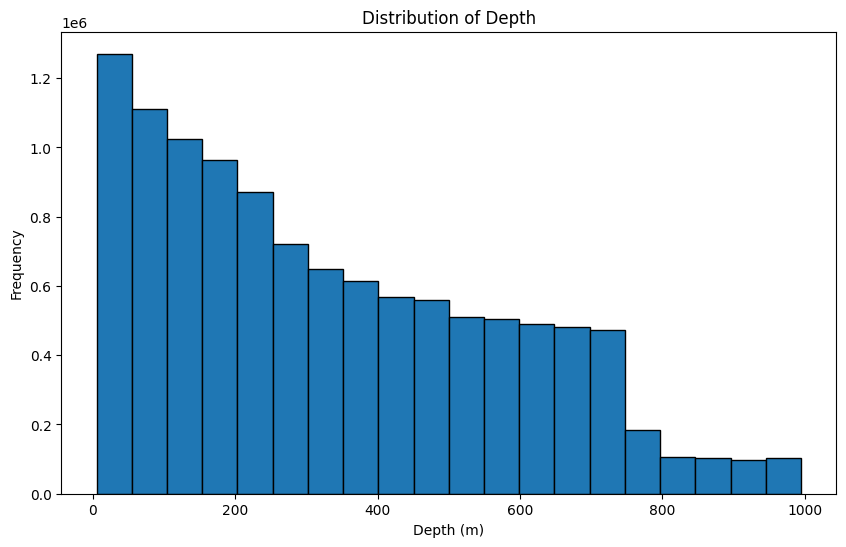

In [6]:
# Data distribution in depth
plt.figure(figsize=(10, 6))
plt.hist(df_ST['Depth_[m]'], bins=20, edgecolor='black')
plt.title('Distribution of Depth')
plt.xlabel('Depth (m)')
plt.ylabel('Frequency')
plt.show()

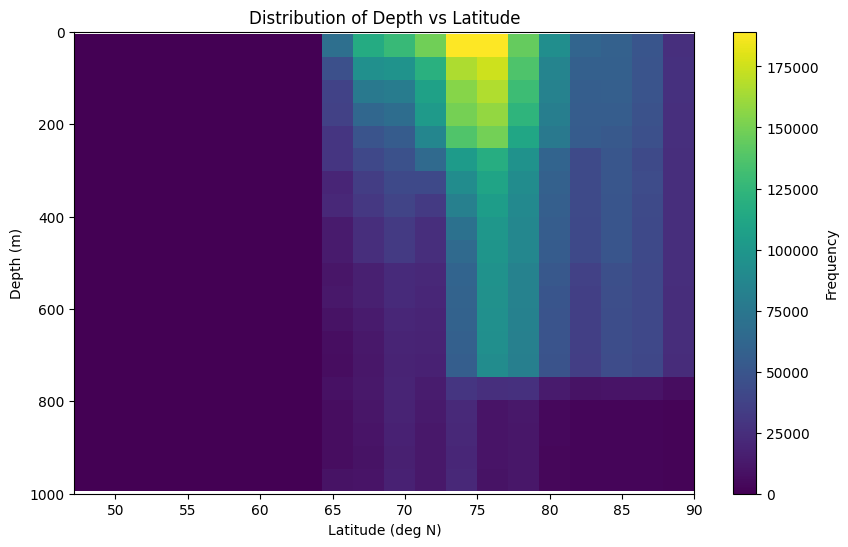

In [19]:
# Data distribution geographically in depth (how many depths per latitude bin)
plt.figure(figsize=(10, 6))
plt.hist2d(df_ST['Latitude_[deg_N]'], df_ST['Depth_[m]'], bins=[20, 20], cmap='viridis')
plt.colorbar(label='Frequency')
plt.ylim(1000,0)
plt.title('Distribution of Depth vs Latitude')
plt.ylabel('Depth (m)')
plt.xlabel('Latitude (deg N)')
plt.show()

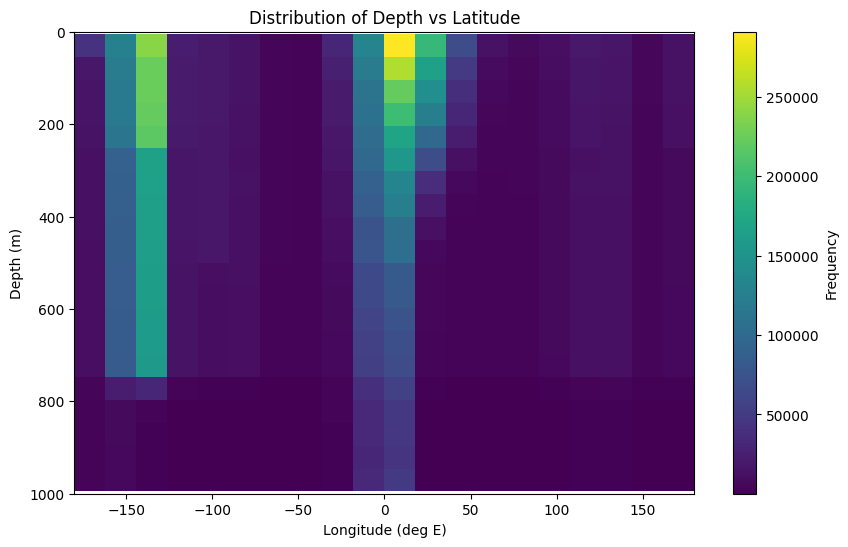

In [22]:
# Data distribution geographically in depth (how many depths per longitude bin)
plt.figure(figsize=(10, 6))
plt.hist2d(df_ST['Longitude_[deg_E]'], df_ST['Depth_[m]'], bins=[20, 20], cmap='viridis')
plt.colorbar(label='Frequency')
plt.ylim(1000,0)
plt.title('Distribution of Depth vs Latitude')
plt.ylabel('Depth (m)')
plt.xlabel('Longitude (deg E)')
plt.show()

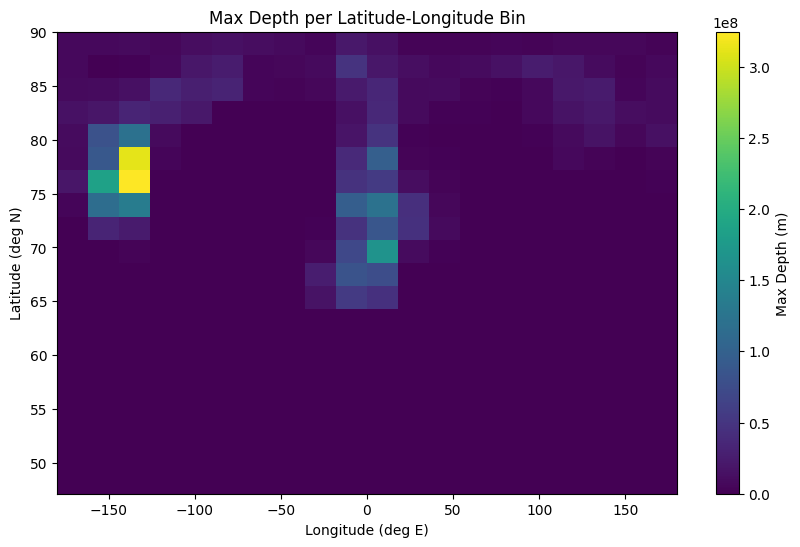

In [23]:
# Plot of max depth per latitude longitude bin
plt.figure(figsize=(10, 6))
plt.hist2d(df_ST['Longitude_[deg_E]'], df_ST['Latitude_[deg_N]'], bins=[20, 20], cmap='viridis', weights=df_ST['Depth_[m]'])
plt.colorbar(label='Max Depth (m)')
plt.title('Max Depth per Latitude-Longitude Bin')
plt.xlabel('Longitude (deg E)')
plt.ylabel('Latitude (deg N)')
plt.show()

In [26]:
def plot_heatmap(ds_cleaned, bin_max=None):
    '''
    ds_cleaned: A dataset containing cleaned data.
    bin_max (optional): The maximum bin value for the heatmap. If not provided, it is calculated as the maximum value of the histogram.
    '''
    # Define the map bounds and resolution
    lon_min, lon_max = -180, 180
    lat_min, lat_max = 45, 90
    latlon_step = 5
    resolution = 'l'  # l for low resolution, h for high resolution

    # Define bin edges for longitude, latitude, and pressure
    lon_bins = np.arange(lon_min, lon_max+1, latlon_step)
    lat_bins = np.arange(lat_min, lat_max+1, latlon_step)

    # Compute max depth per bin instead of profile count
    n_lon = len(lon_bins) - 1
    n_lat = len(lat_bins) - 1
    H = np.zeros((n_lon, n_lat))

    lon_vals = ds_cleaned['Longitude_[deg_E]'].values
    lat_vals = ds_cleaned['Latitude_[deg_N]'].values
    depth_vals = ds_cleaned['Depth_[m]'].values  # adjust column name if needed

    lon_idx = np.digitize(lon_vals, lon_bins) - 1
    lat_idx = np.digitize(lat_vals, lat_bins) - 1

    for i in range(len(lon_vals)):
        li, lj = lon_idx[i], lat_idx[i]
        if 0 <= li < n_lon and 0 <= lj < n_lat:
            if depth_vals[i] > H[li, lj]:
                H[li, lj] = depth_vals[i]

    # Set up the figure and the Basemap instance
    fig = plt.figure(figsize=(8,8), dpi=300)
    m = Basemap(projection='npstere', boundinglat=lat_min, lon_0=0, resolution=resolution)
    m.drawparallels(np.arange(lat_min, lat_max+1, 5), labels=[], linewidth=0.1)
    m.drawmeridians(np.arange(lon_min, lon_max+1, 5), labels=[], linewidth=0.1)

    # Create the X and Y grids for the histogram
    X, Y = np.meshgrid(lon_bins[:-1], lat_bins[:-1])

    new_col = np.arange(lat_min, lat_max, latlon_step)
    Y = np.concatenate((Y, new_col[:, np.newaxis]), axis=1)
    new_col = lon_max * np.ones(len(lat_bins) - 1)
    X = np.concatenate((X, new_col[:, np.newaxis]), axis=1)
    new_row = X[-1]
    X = np.vstack([X, new_row])
    new_row = lat_max * np.ones(np.shape(Y)[1])
    Y = np.vstack([Y, new_row])

    # Create the colored grid using pcolormesh
    cmap = plt.get_cmap('Wistia').copy()
    cmap.set_under(color='white', alpha=1.0)
    cmap.set_over(color='white', alpha=1.0)

    if bin_max is None:
        bin_max = H.max()

    m.pcolormesh(X, Y, H.T, cmap=cmap, vmin=1, vmax=bin_max, latlon=True)
    m.drawcoastlines()
    m.fillcontinents(color='grey', lake_color='lightblue')

    # Add a colorbar
    cbar = m.colorbar(location='bottom', pad="5%")
    cbar.set_label('Max Depth [m]')

    # Set the axis labels and title
    plt.xticks([])
    plt.yticks([])
    plt.title('Max Depth per Bin')

    # Show the plot
    plt.show()
    print(f'bin max={bin_max}')

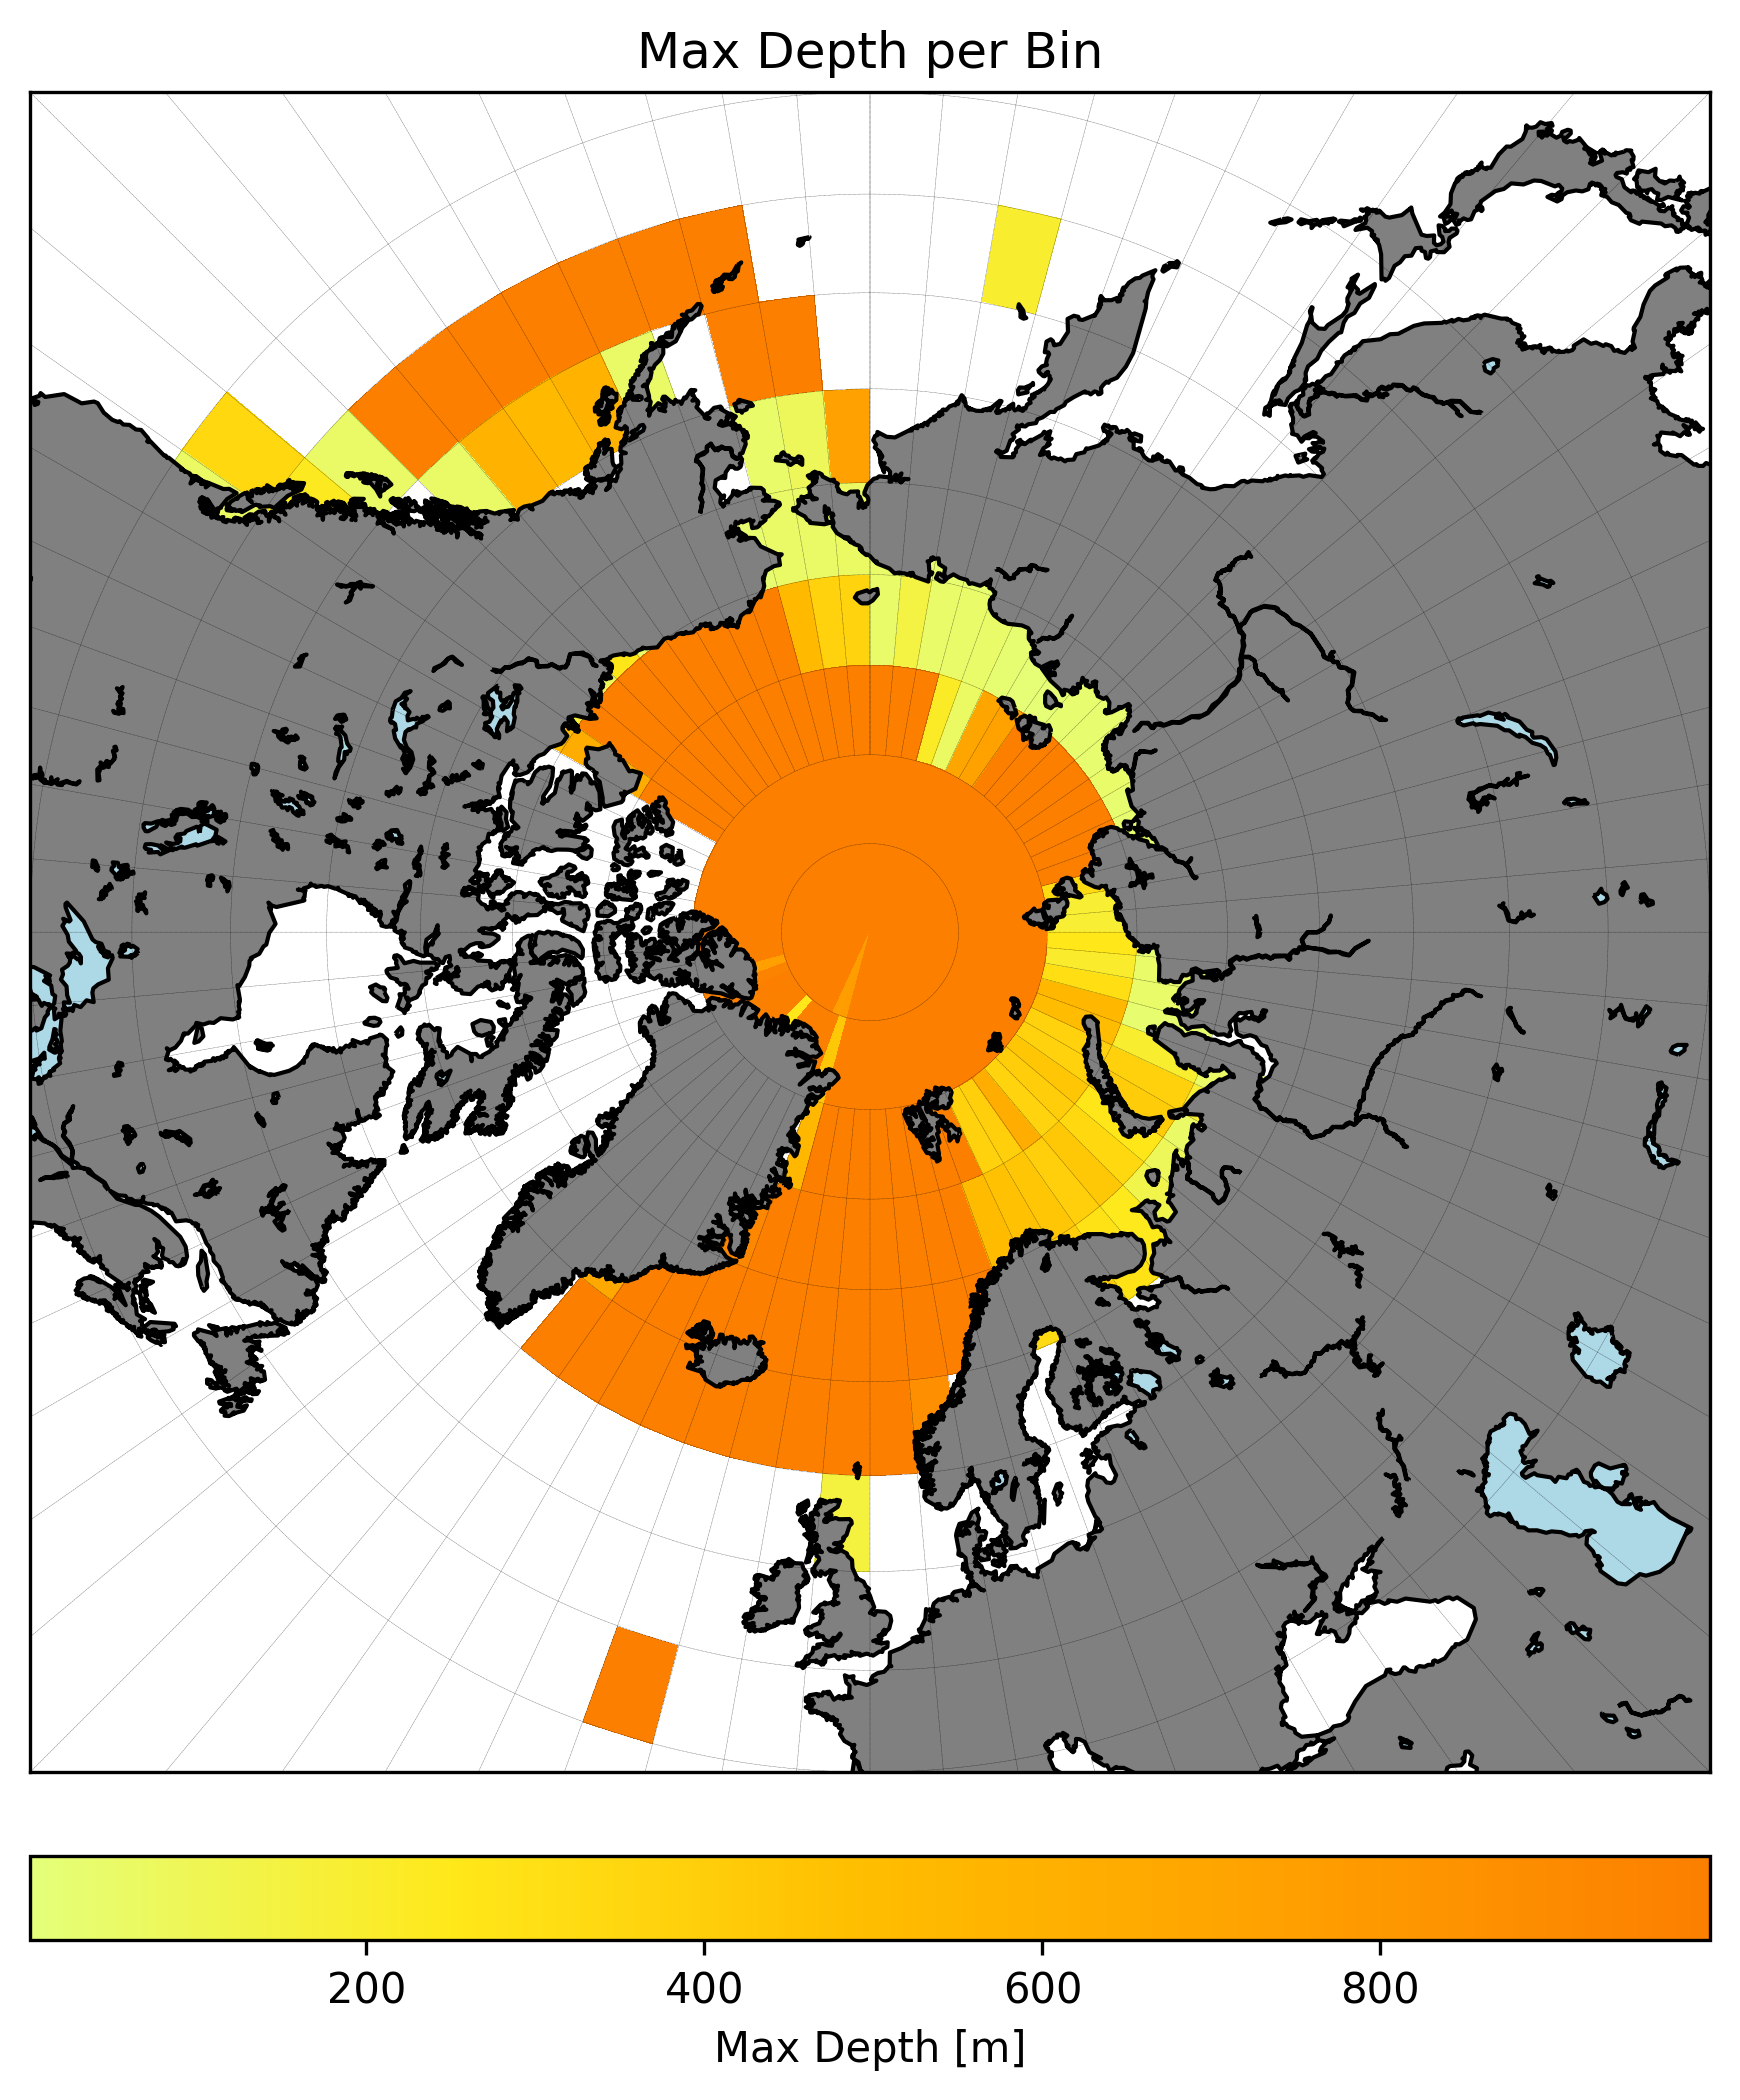

bin max=995.0


In [27]:
plot_heatmap(df_ST)